In [54]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge,Lasso,LinearRegression
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Data loading and initial assessment

In [2]:
df = pd.read_csv("used_cars.csv")
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [3]:
df.shape

(4009, 12)

In [4]:
df.dtypes

brand           object
model           object
model_year       int64
milage          object
fuel_type       object
engine          object
transmission    object
ext_col         object
int_col         object
accident        object
clean_title     object
price           object
dtype: object

In [5]:
df.isna().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [6]:
col = df.columns
col

Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='object')

In [7]:
df.info(memory_usage=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
brand           4009 non-null object
model           4009 non-null object
model_year      4009 non-null int64
milage          4009 non-null object
fuel_type       3839 non-null object
engine          4009 non-null object
transmission    4009 non-null object
ext_col         4009 non-null object
int_col         4009 non-null object
accident        3896 non-null object
clean_title     3413 non-null object
price           4009 non-null object
dtypes: int64(1), object(11)

# Data cleaning

In [8]:
for c in col:
    print(f"{c}: {df[c].nunique()} : {df[c].dtypes} : {df[c].isna().sum()}")

brand: 57 : object : 0
model: 1898 : object : 0
model_year: 34 : int64 : 0
milage: 2818 : object : 0
fuel_type: 7 : object : 170
engine: 1146 : object : 0
transmission: 62 : object : 0
ext_col: 319 : object : 0
int_col: 156 : object : 0
accident: 2 : object : 113
clean_title: 1 : object : 596
price: 1569 : object : 0


In [9]:
df['fuel_type'].unique()

array(['E85 Flex Fuel', 'Gasoline', 'Hybrid', nan, 'Diesel',
       'Plug-In Hybrid', '–', 'not supported'], dtype=object)

In [10]:
df['fuel_type'] = df['fuel_type'].replace(["–","not supported"],"unknown")
df['fuel_type'] = df['fuel_type'].fillna("unknown")
df['fuel_type'].unique()

array(['E85 Flex Fuel', 'Gasoline', 'Hybrid', 'unknown', 'Diesel',
       'Plug-In Hybrid'], dtype=object)

In [11]:
# df['fuel_type'].unique()
df['fuel_type'].isna().sum()

0

In [12]:
df['accident'].unique()

array(['At least 1 accident or damage reported', 'None reported', nan],
      dtype=object)

In [13]:
df['accident'] = df['accident'].replace({'At least 1 accident or damage reported':'yes',
                                        'None reported':'no'})
df['accident'] = df['accident'].fillna('unknown')
df['accident'].unique()

array(['yes', 'no', 'unknown'], dtype=object)

In [14]:
df['clean_title'].unique()

array(['Yes', nan], dtype=object)

In [15]:
df['clean_title'].isna().sum()/df.shape[0]*(100)

14.866550261910701

In [16]:
df['clean_title'] = df['clean_title'].fillna("unknown")
df.isna().sum()

brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
dtype: int64

In [17]:
df['price'].nunique()

1569

In [18]:
df['price'] = df['price'].astype(str)
df['price'] = df['price'].str.replace("$","",regex=False)
df['price'] = df['price'].str.replace(",","",regex=False)
df['price'] = df['price'].astype(float)
df['price'].unique()
df['price'].dtypes

dtype('float64')

In [19]:
df['milage'].unique()

array(['51,000 mi.', '34,742 mi.', '22,372 mi.', ..., '53,705 mi.',
       '714 mi.', '2,116 mi.'], dtype=object)

In [20]:
df['milage'] = df['milage'].astype(str)
df['milage'] = df['milage'].str.replace(",","",regex=False)
df['milage'] = df['milage'].str.replace("mi","",regex=False)
df['milage'] = df['milage'].str.replace(".","",regex=False)
df['milage'] = df['milage'].astype(float)
df['milage'].dtypes

dtype('float64')

In [21]:
df['ext_col'].nunique()

319

In [22]:
df['int_col'].nunique()

156

In [23]:
df['brand'].nunique()

57

In [24]:
df['model'].nunique()

1898

In [25]:
df['model'].unique()

array(['Utility Police Interceptor Base', 'Palisade SEL', 'RX 350 RX 350',
       ..., 'Martin DB7 Vantage Volante', 'Impala 2LZ', 'Taycan'],
      dtype=object)

In [26]:
df['model_year'].unique()

array([2013, 2021, 2022, 2015, 2016, 2017, 2001, 2020, 2019, 2003, 2018,
       2023, 2000, 2006, 2011, 2012, 2007, 2014, 2005, 2009, 2010, 2004,
       2008, 1997, 1999, 1993, 2002, 1998, 2024, 1996, 1974, 1992, 1995,
       1994], dtype=int64)

In [27]:
df['engine'].unique()

array(['300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability',
       '3.8L V6 24V GDI DOHC', '3.5 Liter DOHC', ...,
       '136.0HP 1.8L 4 Cylinder Engine Gasoline Fuel',
       '270.0HP 2.0L 4 Cylinder Engine Gasoline Fuel',
       '420.0HP 5.9L 12 Cylinder Engine Gasoline Fuel'], dtype=object)

In [28]:
df['transmission'].nunique()

62

# feature engineering

In [29]:
df['HP'] = df['engine'].str.extract(r'(\d+)HP').astype(float)
df['eng_size'] = df['engine'].str.extract(r'(\d+\.?d*)L').astype(float)
df['cylinder'] = df['engine'].str.extract(r'(\d+)\s*Cylinder').astype(float)
df.drop(columns=['engine'])
# df.dtypes
df.isna().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type         0
engine            0
transmission      0
ext_col           0
int_col           0
accident          0
clean_title       0
price             0
HP              808
eng_size        377
cylinder        945
dtype: int64

In [30]:
df['transmission'].astype(str).str.lower()
df['transmission'] = df['transmission'].replace({r'.*Automatic*.':'automatic',
                                                r'.*Manual*.':'manual',
                                                r'.*CVT*.':'cvt'},regex=True)


In [31]:
df['transmission'].unique()

array(['6-Speed A/T', 'automatic', '7-Speed A/T', 'F', 'A/T',
       '8-Speed A/T', 'Transmission w/Dual Shift Mode', '6-Speed M/T',
       '10-Speed A/T', '9-Speed A/T', '5-Speed A/T', '1-Speed A/T', 'cvt',
       'automaticwith Auto-Shift', 'cvtF', 'M/T', 'cvtTransmission',
       '4-Speed A/T', '7-Speed M/T', '8-SPEED AT', '5-Speed M/T',
       'manual', 'Variable', '2', 'automatic 9-Spd 9G-Tronic',
       'automatic 8-Spd', 'manualModes', '–', 'Auto, 6-Spd w/CmdShft',
       'Transmission Overdrive Switch', 'automatic 8-Spd PDK Dual-Clutch',
       'automatic 8-Spd Dual-Clutch', '6-Speed',
       'Single-Speed Fixed Gear', 'automatic 10-Spd', '7-Speed',
       'automatic 7-Spd S tronic Dual-Clutch', 'manual 6-Spd',
       'automaticwith O', '6 Speed At/Mt', '8-SPEED A/T',
       'automaticwith Overdrive', 'SCHEDULED FOR OR IN PRODUCTION',
       '2-Speed A/T', '6 Speed Mt'], dtype=object)

In [32]:
for col in ['HP',"eng_size",'cylinder']:
    df[col] = df[col].fillna(df[col].median())

In [33]:
column = df.columns
for x in column:
    print(f"{x}: {df[x].isna().sum()} : {df[x].dtypes} : {df[x].nunique()}")

brand: 0 : object : 57
model: 0 : object : 1898
model_year: 0 : int64 : 34
milage: 0 : float64 : 2818
fuel_type: 0 : object : 6
engine: 0 : object : 1146
transmission: 0 : object : 45
ext_col: 0 : object : 319
int_col: 0 : object : 156
accident: 0 : object : 3
clean_title: 0 : object : 2
price: 0 : float64 : 1569
HP: 0 : float64 : 3
eng_size: 0 : float64 : 12
cylinder: 0 : float64 : 7


In [34]:
df['age'] = 2026-df['model_year']

# Exploratory data analysis

In [35]:
numeric = df._get_numeric_data()
numeric = numeric.drop(columns=['model_year'])
numeric.head(2)

,milage,price,HP,eng_size,cylinder,age
0,51000.0,10300.0,0.0,7.0,6.0,13
1,34742.0,38005.0,0.0,8.0,6.0,5


In [36]:
num_col = numeric.columns
for x in num_col:
    print(f"{x}: {numeric[x].skew()}")

milage: 1.1599748853042458
price: 19.513551204216057
HP: 49.805413486515064
eng_size: 8.384797241285982
cylinder: 0.47724557145357405
age: 1.0892312577318568


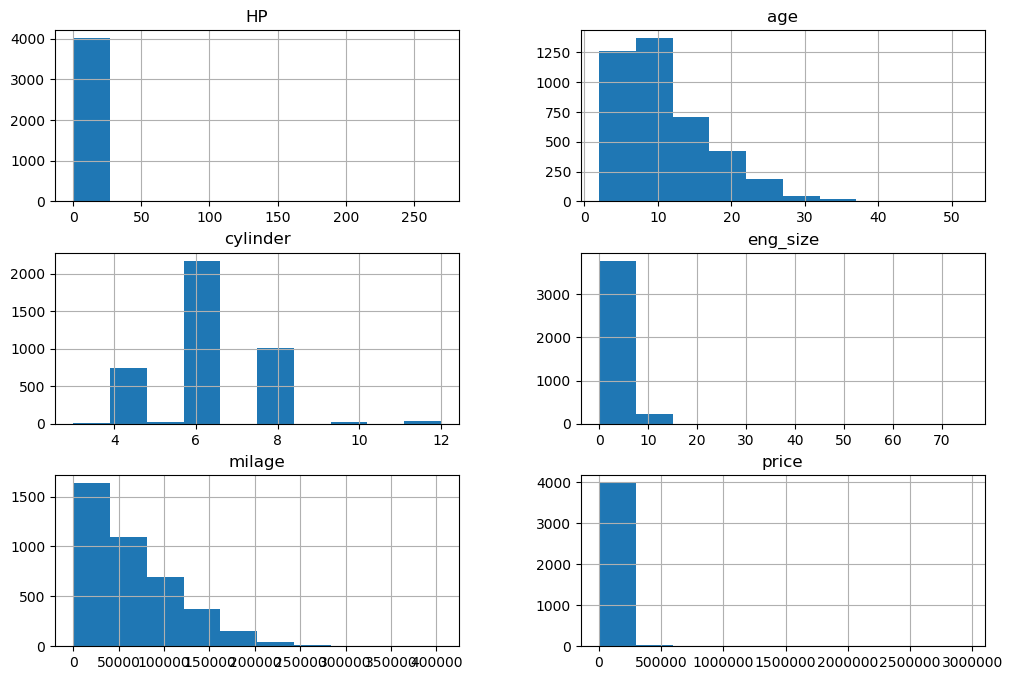

In [37]:
numeric.hist(figsize=(12,8))
plt.show()

In [38]:
numeric.corr()['price']

milage     -0.305528
price       1.000000
HP         -0.002992
eng_size   -0.030888
cylinder    0.149428
age        -0.199496
Name: price, dtype: float64

In [39]:
character = df.drop(columns=numeric.columns)
character = character.drop(columns=['transmission','ext_col','int_col','engine','model','model_year'])
character.head(2)

,brand,fuel_type,accident,clean_title
0,Ford,E85 Flex Fuel,yes,Yes
1,Hyundai,Gasoline,yes,Yes


In [40]:
cl_data = pd.concat([numeric,character],axis=1)
cl_data.head()

,milage,price,HP,eng_size,cylinder,age,brand,fuel_type,accident,clean_title
0,51000.0,10300.0,0.0,7.0,6.0,13,Ford,E85 Flex Fuel,yes,Yes
1,34742.0,38005.0,0.0,8.0,6.0,5,Hyundai,Gasoline,yes,Yes
2,22372.0,54598.0,0.0,4.0,6.0,4,Lexus,Gasoline,no,unknown
3,88900.0,15500.0,0.0,5.0,6.0,11,INFINITI,Hybrid,no,Yes
4,9835.0,34999.0,0.0,0.0,6.0,5,Audi,Gasoline,no,unknown


# preprocessing

In [41]:
cl_data = pd.get_dummies(cl_data,columns=['brand','fuel_type','accident','clean_title'])

In [42]:
cl_data.shape

(4009, 74)

In [43]:
cl_data['price'] = np.log1p(cl_data['price'])
cl_data['milage'] = np.log1p(cl_data['milage'])

In [44]:
x = cl_data.drop(columns=['price'])
y = cl_data['price']
z = x.columns
print('price' in z)

False


In [45]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)


(3207, 73)
(802, 73)
(3207,)
(802,)


In [46]:
sc = StandardScaler()
train_scaled = sc.fit_transform(x_train)
train_test = sc.fit(x_test)

# model training

In [47]:
model1 = LinearRegression()
model1.fit(x_train,y_train)
p_train = model1.predict(x_train)
p_test = model1.predict(x_test)

# model evaluation

In [48]:
r2_train = r2_score(y_train,p_train)
r2_test = r2_score(y_test,p_test)
rmse_train = np.sqrt(mean_squared_error(y_train,p_train))
rmse_test = np.sqrt(mean_squared_error(y_test,p_test))
print("r2 train:",r2_train)
print("r2 test:",r2_test)
print("rmse train:",rmse_train)
print("rmse test:",rmse_test)

r2 train: 0.7718657029218771
r2 test: 0.6958768844014301
rmse train: 0.40199146078322706
rmse test: 0.48663660948451104


# ridge model

In [49]:
ridge_model = Ridge()
para_grid = {"alpha":[0.01,0.1,1,10,100]}
grid = GridSearchCV(
        estimator = ridge_model,
        param_grid = para_grid,
        cv = 5,
        scoring = "neg_mean_squared_error")

grid.fit(x_train,y_train)
print("best alpha:",grid.best_params_)
best_model = grid.best_estimator_
y_pred = best_model.predict(x_test)
print("mse:",mean_squared_error(y_test,y_pred))
print("r2 score on train:",best_model.score(x_train,y_train))
print("r2 score on train:",best_model.score(x_test,y_test))

best alpha: {'alpha': 0.1}
mse: 0.236700823383518
r2 score on train: 0.7718504124771829
r2 score on train: 0.6960237560512967


In [50]:
ridge_model = Lasso()
para_grid = {"alpha":[0.01,0.1,1,10,100]}
grid = GridSearchCV(
        estimator = ridge_model,
        param_grid = para_grid,
        cv = 5,
        scoring = "neg_mean_squared_error")

grid.fit(x_train,y_train)
print("best alpha:",grid.best_params_)
best_model = grid.best_estimator_
y_pred = best_model.predict(x_test)
print("mse:",mean_squared_error(y_test,y_pred))
print("r2 score on train:",best_model.score(x_train,y_train))
print("r2 score on train:",best_model.score(x_test,y_test))

best alpha: {'alpha': 0.01}
mse: 0.27964755901279176
r2 score on train: 0.6902202318023756
r2 score on train: 0.6408706425139925


# feature importance

In [51]:
result = permutation_importance(
model1,x_test,y_test,scoring='neg_mean_squared_error',random_state=42)
imp = pd.DataFrame({
'feature':x.columns,
'importance':result.importances_mean}).sort_values(by='importance',ascending=False)
print(imp.head(10))

              feature  importance
4                 age    0.280336
0              milage    0.192746
3            cylinder    0.077886
48      brand_Porsche    0.045143
30  brand_Lamborghini    0.026360
51  brand_Rolls-Royce    0.010076
10      brand_Bentley    0.008048
24      brand_Hyundai    0.007933
29          brand_Kia    0.006384
44       brand_Nissan    0.006181


# Tree models

In [52]:
model = DecisionTreeRegressor(random_state=42)
para_grid = {"max_depth":[3,5,10,None],
            "min_samples_split":[2,5,10],
            "min_samples_leaf":[1,2,5]}
grid = GridSearchCV(
        estimator = model,
        param_grid = para_grid,
        cv = 5,
        scoring = "neg_mean_squared_error")

grid.fit(x_train,y_train)
best_tree = grid.best_estimator_
y_pred_test_tree = best_tree.predict(x_test)
y_pred_train_tree = best_tree.predict(x_train)
#print("mse:",mean_squared_error(y_test,y_pred_t))
print("r2 score on test:",r2_score(y_test,y_pred_test_tree))
print("r2 score on train:",r2_score(y_train,y_pred_train_tree))


r2 score on test: 0.6875373917705941
r2 score on train: 0.8412386693884087


# RandomForest regressor 

In [59]:
random_model = RandomForestRegressor(random_state = 42)
para_grid = {"n_estimators":[50,100,200],
             "max_depth":[None,5,10],
            "min_samples_split":[2,5,10],
            "min_samples_leaf":[1,2,5]}

grid = GridSearchCV(
        estimator = random_model,
        param_grid = para_grid,
        cv = 5,
        scoring = "neg_mean_squared_error",
        n_jobs =-1)

grid.fit(x_train,y_train)
best_Rtree=grid.best_estimator_
y_pred_test_tree = best_Rtree.predict(x_test)
y_pred_train_tree = best_Rtree.predict(x_train)
print("r2 score on test:",r2_score(y_test,y_pred_test_tree))
print("r2 score on train:",r2_score(y_train,y_pred_train_tree))


r2 score on test: 0.7654796010848661
r2 score on train: 0.9557252096870529
